# Influence of `T_viab` (viability temperature) on signal fidelity and recovery, at fixed `mu=50`

`T_viab` sets how sharply the viability score shapes each cell's expected capsid output in
`produce_capsids` (`sequence_classesV1.py`): `rate = alpha * E * exp(score / T_viab)`. Small
`T_viab` -> `exp(score/T_viab)` is extremely peaked, so capsid counts get dominated by whichever
sequences happen to have the highest score (sharp selection, huge dynamic range). Large `T_viab`
-> `score/T_viab -> 0`, every sequence's rate converges to the same `alpha * E`, i.e. production
becomes essentially uniform and the viability score stops mattering.

`mu = rho * N1 / d0` (mean HEK cells transfected per sequence -- see the sibling
`mu_HEK_multiplicity_sweep.ipynb`) is held FIXED at `mu=50` throughout, deep in that notebook's
signal-fidelity plateau, so any effect seen here is attributable to `T_viab`, not to `mu`.

**Question.** As `T_viab` sweeps from sharp to flat, how do (a) the Pearson correlation between
the true noiseless viability score and the NGS-measured `target1`, and (b) the top-1000 recovery
between the three pairwise views (GT, protocol-measured `target1`, MLP-predicted `target1`) on a
held-out test fold, respond? Same `ProfileMLP` / train-test-split / `topk_recovery` convention as
`mu_HEK_multiplicity_sweep.ipynb` section 7.

## 0. Setup

In [1]:
import os
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
# Must run before the first `import jax` anywhere -- same convention as the sibling notebooks.

In [2]:
import jax
import jax.numpy as jnp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm

from flax import nnx
import optax

from sequence_classesV1 import *
from analysisV1 import *
from initialize_weights import load_F_viab_aav9_mlp, load_J_viab_aav9_mlp, NUM_AMINO_ACIDS, NUM_POSITIONS

print(f"JAX backend: {jax.default_backend()} -- devices: {jax.devices()}")

/home/spark0735/MERLIN_YASSINE/Directed-Evolution-loop/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


JAX backend: gpu -- devices: [CudaDevice(id=0)]


## 1. Ground truth and fixed pool

Identical real AAV9 `F_viab`/`J_viab`, permuted `F_sel`/`J_sel` and 20,000-sequence pool as
`mu_HEK_multiplicity_sweep.ipynb` (`F_sel`/`J_sel` are constructed but never used below -- only
the viability channel, `target1`, is swept here).

In [3]:
F_viab = load_F_viab_aav9_mlp()
J_viab = load_J_viab_aav9_mlp()

key_F, key_J = jax.random.split(jax.random.key(0), 2)
sigma_F = jax.random.permutation(key_F, NUM_AMINO_ACIDS)
F_sel   = F_viab[sigma_F, :]
sigma_J = jax.random.permutation(key_J, NUM_AMINO_ACIDS)
J_sel   = J_viab[:, :, sigma_J, :][:, :, :, sigma_J]

key_pool = jax.random.key(1)
N = 30_000
sequences = jax.random.randint(key_pool, shape=(N, NUM_POSITIONS), minval=0, maxval=NUM_AMINO_ACIDS)
d0 = N

print(f"F_viab shape: {F_viab.shape}   J_viab shape: {J_viab.shape}   sequences: {N:,}")

F_viab shape: (20, 7)   J_viab shape: (7, 7, 20, 20)   sequences: 30,000


## 2. Fixed 50,000-sequence evaluation pool (SAME key in every notebook)

A separate, FIXED `50,000`-sequence pool, generated once with a hardcoded key
(`EVAL_POOL_KEY_SEED=999`, `EVAL_POOL_SIZE=50_000` -- the exact same pair of values used in
`deeper_mlp/diversity_sweep_deeper_mlp.ipynb` and every other notebook that wants directly
comparable top-K recovery numbers), held out from training entirely. Every model trained at
every `T_viab` gets evaluated on this SAME `50,000` sequences (in addition to this
notebook's own in-sweep test fold), so top-1000 recovery becomes comparable both across
`T_viab` within this notebook AND across every other sweep notebook using the same fixed
key -- independent of this notebook's own pool size or train/test split.

In [4]:
EVAL_POOL_KEY_SEED = 999   # fixed across every notebook -- reuse this exact value for comparable numbers
EVAL_POOL_SIZE     = 50_000

def compute_score_array(seq, F, J, L=NUM_POSITIONS):
    """Noiseless ground-truth score, decoupled from any Protocol instance -- same formula as
    Protocol.compute_score, applied directly to an arbitrary sequence array."""
    scores = jnp.sum(F[seq, jnp.arange(L)], axis=1)
    for i in range(L):
        for j in range(i + 1, L):
            scores = scores + J[i, j, seq[:, i], seq[:, j]]
    return scores

eval_sequences = jax.random.randint(jax.random.key(EVAL_POOL_KEY_SEED),
                                     shape=(EVAL_POOL_SIZE, NUM_POSITIONS),
                                     minval=0, maxval=NUM_AMINO_ACIDS)
eval_viab_score = np.asarray(compute_score_array(eval_sequences, F_viab, J_viab))
X_eval = np.eye(NUM_AMINO_ACIDS, dtype=np.float32)[np.asarray(eval_sequences)].reshape(EVAL_POOL_SIZE, -1)

print(f"fixed evaluation pool: {EVAL_POOL_SIZE:,} sequences (key seed={EVAL_POOL_KEY_SEED})")
print(f"GT score range on eval pool: [{eval_viab_score.min():.2f}, {eval_viab_score.max():.2f}]")

fixed evaluation pool: 50,000 sequences (key seed=999)
GT score range on eval pool: [-12.48, 8.34]


## 3. Fixed `mu=50`, `T_viab` grid, and train/test split

`rho=RHO_REF` (same baseline as `mu_HEK_multiplicity_sweep.ipynb`), `N1` solved so that
`rho * N1 / d0 == 50` exactly. `T_VIAB_GRID` spans two orders of magnitude around the project's
default (`T_viab=0.5`-`1`, see `sequence_classesV1.py` module-level constants); the lower bound
(`0.2`) is chosen to stay safely clear of `float32` overflow in `exp(score / T_viab)` -- the
pool's true score reaches `~8.3` (checked separately), and `exp(8.3 / 0.1)` alone already exceeds
`float32`'s range before even multiplying by `alpha` or the per-cell noise `E`.

In [5]:
RHO_REF  = 1e-3
MU_FIXED = 50
N1_FIXED = MU_FIXED * d0 / RHO_REF

T_VIAB_GRID = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1, 2, 5, 10, 20, 50]
eps = 1.0

protocol = ProtocolV3(multinomialNGS=True, N0=1_000_000_000, N1=N1_FIXED,
        dilution_factor=10, sequences=sequences, D=1e9,
        F_viab=F_viab, J_viab=J_viab, F_sel=F_sel, J_sel=J_sel,
        noise_viab=0.5, noise_sel=0.5, T_sel=1, T_viab=1,
        )
protocol._rho = float(RHO_REF)
viab_score = np.array(protocol.compute_score(F_viab, J_viab))
original_T_viab = protocol._T_viab

print(f"mu = {protocol._rho * protocol.N1 / d0:.2f}")
print(f"T_viab grid: {T_VIAB_GRID}")

mu = 50.00
T_viab grid: [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1, 2, 5, 10, 20, 50]


In [6]:
K_TOPK = 1000

X_all = np.eye(NUM_AMINO_ACIDS, dtype=np.float32)[np.asarray(sequences)].reshape(N, -1)
idx_train, idx_test = train_test_split(np.arange(N), test_size=0.3, random_state=0)
X_train_full, X_test = X_all[idx_train], X_all[idx_test]
viab_score_test = viab_score[idx_test]
k_frac_test = K_TOPK / len(idx_test)

print(f"pool: {N:,}   train: {len(idx_train):,}   test: {len(idx_test):,}   "
      f"top-{K_TOPK} = top-{100 * k_frac_test:.1f}% of the test set")

pool: 30,000   train: 21,000   test: 9,000   top-1000 = top-11.1% of the test set


## 4. Simulate the SAME experimental configuration on the fixed eval pool

To get a genuine `GT<->protocol` recovery number on the fixed `50,000`-sequence eval pool
(section 2), build a SEPARATE `ProtocolV3` object dedicated to it alone -- NOT mixed into the
training pool (that would dilute `D`/`d0` and distort `mu`). `N1` is recomputed for the eval
pool's own `d0=50,000` to keep the same `mu`. Same reused-object / advancing-PRNG-key convention
as `protocol` itself: `protocol_eval._T_viab` gets mutated to match every sweep point, right
alongside `protocol._T_viab`, in section 6's loop.

In [7]:
N1_eval = MU_FIXED * EVAL_POOL_SIZE / RHO_REF
print(f"N1_eval = {N1_eval}")

protocol_eval = ProtocolV3(multinomialNGS=True, N0=N1_eval*10, N1=N1_eval,
        dilution_factor=10, sequences=eval_sequences, D=1e9,
        F_viab=F_viab, J_viab=J_viab, F_sel=F_sel, J_sel=J_sel,
        noise_viab=0.5, noise_sel=0.5, T_sel=1, T_viab=1,
        )
protocol_eval._rho = float(RHO_REF)

print(f"mu (eval pool) = {protocol_eval._rho * protocol_eval.N1 / EVAL_POOL_SIZE:.2f}")

N1_eval = 2500000000.0
mu (eval pool) = 50.00


## 5. `ProfileMLP`: same architecture/training convention as the sibling notebooks

Identical `ProfileMLP` (Linear + BatchNorm + Dropout + gelu, twice, then a scalar linear head)
and `train_profile_mlp` (warmup-cosine-decay AdamW, early stopping on val MSE) as
`mu_HEK_multiplicity_sweep.ipynb` section 7.3.

In [8]:
def split_train_val(X, y, val_frac=0.15, seed=0):
    rng   = np.random.default_rng(seed)
    idx   = rng.permutation(len(X))
    n_val = int(len(X) * val_frac)
    val_idx, train_idx = idx[:n_val], idx[n_val:]
    return X[train_idx], y[train_idx], X[val_idx], y[val_idx]


class ProfileMLP(nnx.Module):
    """
    MLP over the one-hot encoded per-position sequence (L=7 positions x A=20 amino acids
    -> 140 indicator features) -> scalar score. Identical to the sibling notebooks' ProfileMLP
    (Linear + BatchNorm + Dropout + gelu).
    """

    def __init__(self, input_dim: int, hidden_dims: tuple[int, int] = (128, 64),
                 dropout_rate: float = 0.1, *, rngs: nnx.Rngs):
        h1, h2 = hidden_dims
        self.linear1    = nnx.Linear(input_dim, h1, rngs=rngs)
        self.batchnorm1 = nnx.BatchNorm(h1, use_running_average=False, rngs=rngs)
        self.dropout1   = nnx.Dropout(rate=dropout_rate, rngs=rngs)
        self.linear2    = nnx.Linear(h1, h2, rngs=rngs)
        self.batchnorm2 = nnx.BatchNorm(h2, use_running_average=False, rngs=rngs)
        self.dropout2   = nnx.Dropout(rate=dropout_rate, rngs=rngs)
        self.linear3    = nnx.Linear(h2, 1, rngs=rngs)

    def __call__(self, x, train: bool, rngs: nnx.Rngs = None):
        x = self.linear1(x)
        self.batchnorm1.use_running_average = not train
        x = self.batchnorm1(x)
        x = nnx.gelu(x)
        x = self.dropout1(x, rngs=rngs) if train else x
        x = self.linear2(x)
        self.batchnorm2.use_running_average = not train
        x = self.batchnorm2(x)
        x = nnx.gelu(x)
        x = self.dropout2(x, rngs=rngs) if train else x
        x = self.linear3(x)
        return x[:, 0]

In [9]:
@nnx.jit
def train_step(model, optimizer, x, y, rngs):
    """
    x : (batch, L*A) one-hot encoded per-position amino-acid indicators
    y : (batch,) target log enrichment
    """
    def loss_fn(model, rngs):
        y_pred = model(x, train=True, rngs=rngs)
        return jnp.mean((y_pred - y) ** 2)

    loss, grads = nnx.value_and_grad(loss_fn)(model, rngs)
    optimizer.update(model, grads)
    return loss


@nnx.jit
def eval_step(model, x, y):
    y_pred = model(x, train=False)
    return jnp.mean((y_pred - y) ** 2)


@nnx.jit
def predict_log_enrichment(model, x):
    return model(x, train=False)


def train_profile_mlp(X_train, y_train, X_val, y_val, hidden_dims=(128, 64),
                       dropout_rate=0.1, epochs=300, batch_size=256,
                       peak_lr=1e-3, final_lr=1e-5, weight_decay=0,
                       patience=20, seed=0, verbose=True):
    rngs = nnx.Rngs(seed)
    model = ProfileMLP(input_dim=X_train.shape[1], hidden_dims=hidden_dims,
                        dropout_rate=dropout_rate, rngs=rngs)

    n_train         = X_train.shape[0]
    steps_per_epoch = max(n_train // batch_size, 1)
    total_steps     = steps_per_epoch * epochs

    lr_schedule_fn = optax.warmup_cosine_decay_schedule(
        init_value=0., peak_value=peak_lr,
        warmup_steps=int(total_steps * 0.1),
        decay_steps=int(total_steps * 0.9),
        end_value=final_lr,
    )
    optimizer = nnx.Optimizer(
        model, optax.adamw(learning_rate=lr_schedule_fn, weight_decay=weight_decay), wrt=nnx.Param
    )

    X_train, y_train = jnp.asarray(X_train), jnp.asarray(y_train)
    X_val,   y_val   = jnp.asarray(X_val),   jnp.asarray(y_val)

    shuffle_key = jax.random.key(seed)
    best_val, best_state, bad_epochs = float("inf"), None, 0

    for epoch in range(epochs):
        shuffle_key, perm_key = jax.random.split(shuffle_key)
        perm = jax.random.permutation(perm_key, n_train)
        Xs, ys = X_train[perm], y_train[perm]

        for start in range(0, n_train - n_train % batch_size, batch_size):
            xb = Xs[start:start + batch_size]
            yb = ys[start:start + batch_size]
            train_step(model, optimizer, xb, yb, rngs)

        val_loss = float(eval_step(model, X_val, y_val))
        if val_loss < best_val - 1e-6:
            best_val, bad_epochs = val_loss, 0
            best_state = nnx.state(model)
        else:
            bad_epochs += 1
            if bad_epochs >= patience:
                if verbose:
                    print(f"  early stop at epoch {epoch}, best val MSE = {best_val:.4f}")
                break

    if best_state is not None:
        nnx.update(model, best_state)
    return model, best_val

## 6. Sweep: one fresh `loop_DE()` + one fresh `ProfileMLP` per `T_viab`

For each `T_viab`: mutate `protocol._T_viab` in place (same reused `protocol` object /
advancing-PRNG-key convention as the mu sweep), reset `lambda0`, run one `loop_DE()` round to get
`target1`, train a fresh `ProfileMLP` on the train fold, then compare on the held-out test fold:
Pearson `r` and top-`K_TOPK` recovery, each across the three pairwise views (GT, protocol, MLP).
`protocol._T_viab` is restored to its original value afterward.

In [10]:
records = []

try:
    for T_viab in tqdm(T_VIAB_GRID, desc="T_viab sweep"):
        protocol._T_viab = float(T_viab)
        protocol.lambda0 = jnp.full(protocol.d0, protocol.N0 / protocol.d0)
        protocol_eval._T_viab = float(T_viab)
        protocol_eval.lambda0 = jnp.full(protocol_eval.d0, protocol_eval.N0 / protocol_eval.d0)

        _bio_row, ngs_row = protocol.loop_DE()
        lambda0p, lambda2p, _lambda3p = (np.asarray(a) for a in ngs_row)
        target1 = np.log((lambda2p + eps) / (lambda0p + eps))
        _bio_row_eval, ngs_row_eval = protocol_eval.loop_DE()
        lambda0p_eval, lambda2p_eval, _lambda3p_eval = (np.asarray(a) for a in ngs_row_eval)
        target1_eval = np.log((lambda2p_eval + eps) / (lambda0p_eval + eps))
        target1_train, target1_test = target1[idx_train], target1[idx_test]

        Xtr, ytr, Xva, yva = split_train_val(X_train_full, target1_train, val_frac=0.15, seed=0)
        model, val_mse = train_profile_mlp(Xtr, ytr, Xva, yva, epochs=300, patience=20, verbose=False)
        pred_test = np.asarray(predict_log_enrichment(model, jnp.asarray(X_test)))
        pred_eval = np.asarray(predict_log_enrichment(model, jnp.asarray(X_eval)))

        records.append(dict(
            T_viab=T_viab,
            r_gt_protocol=pearson(viab_score_test, target1_test),
            r_gt_mlp=pearson(viab_score_test, pred_test),
            r_protocol_mlp=pearson(target1_test, pred_test),
            rec_gt_protocol=topk_recovery(viab_score_test, target1_test, k=K_TOPK),
            rec_gt_mlp=topk_recovery(viab_score_test, pred_test, k=K_TOPK),
            rec_protocol_mlp=topk_recovery(target1_test, pred_test, k=K_TOPK),
            rec_gt_mlp_eval=topk_recovery(eval_viab_score, pred_eval, k=K_TOPK),
            r_gt_protocol_eval=pearson(eval_viab_score, target1_eval),
            rec_gt_protocol_eval=topk_recovery(eval_viab_score, target1_eval, k=K_TOPK),
            r_protocol_mlp_eval=pearson(target1_eval, pred_eval),
            rec_protocol_mlp_eval=topk_recovery(target1_eval, pred_eval, k=K_TOPK),
        ))
finally:
    protocol._T_viab = original_T_viab
    protocol_eval._T_viab = original_T_viab

T_viab_sweep_df = pd.DataFrame(records)
T_viab_sweep_df

T_viab sweep: 100%|██████████| 15/15 [13:55<00:00, 55.71s/it]


,T_viab,r_gt_protocol,r_gt_mlp,r_protocol_mlp,rec_gt_protocol,rec_gt_mlp,rec_protocol_mlp,rec_gt_mlp_eval,r_gt_protocol_eval,rec_gt_protocol_eval,r_protocol_mlp_eval,rec_protocol_mlp_eval
0,0.1,0.863743,0.886578,0.951650,0.283,0.227,0.300,0.002,0.858353,0.055,0.947708,0.046
1,0.2,0.885287,0.900107,0.972869,0.383,0.399,0.397,0.005,0.879829,0.074,0.970654,0.069
2,0.3,0.904196,0.908114,0.983676,0.547,0.708,0.548,0.074,0.897289,0.098,0.982037,0.101
3,0.4,0.921549,0.922027,0.987212,0.827,0.863,0.781,0.255,0.913150,0.149,0.985388,0.145
4,0.5,0.938536,0.937520,0.987512,0.985,0.886,0.885,0.608,0.929808,0.266,0.986268,0.272
5,0.6,0.956346,0.953765,0.988644,0.974,0.904,0.906,0.745,0.947809,0.633,0.987560,0.570
6,0.7,0.973430,0.969780,0.988921,0.976,0.902,0.906,0.783,0.966529,0.937,0.988042,0.766
7,0.8,0.986693,0.982828,0.989393,0.970,0.910,0.906,0.797,0.981977,0.937,0.988665,0.779
8,0.9,0.993734,0.989464,0.989677,0.959,0.916,0.910,0.783,0.990870,0.921,0.988922,0.765
9,1.0,0.996418,0.992599,0.990667,0.969,0.911,0.907,0.799,0.994951,0.911,0.989981,0.775


## 7. Pearson correlation vs `T_viab`

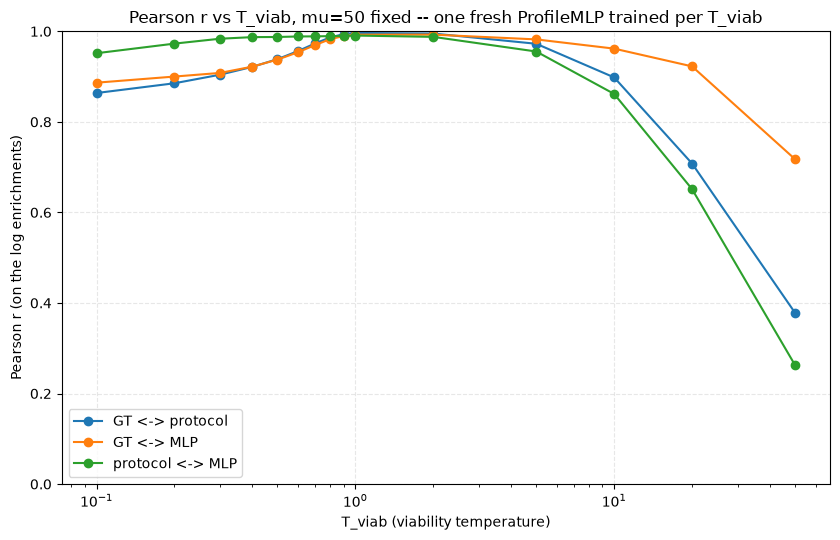

In [11]:
fig, ax = plt.subplots(figsize=(8.5, 5.5))
ax.plot(T_viab_sweep_df["T_viab"], T_viab_sweep_df["r_gt_protocol"],  "o-", label="GT <-> protocol")
ax.plot(T_viab_sweep_df["T_viab"], T_viab_sweep_df["r_gt_mlp"],       "o-", label="GT <-> MLP")
ax.plot(T_viab_sweep_df["T_viab"], T_viab_sweep_df["r_protocol_mlp"], "o-", label="protocol <-> MLP")
ax.set_xscale("log")
ax.set_ylim(0, 1)
ax.set_xlabel("T_viab (viability temperature)")
ax.set_ylabel("Pearson r (on the log enrichments)")
ax.set_title(f"Pearson r vs T_viab, mu={MU_FIXED} fixed -- one fresh ProfileMLP trained per T_viab")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.3)
fig.tight_layout()
plt.show()

## 8. Top-1000 recovery vs `T_viab` (in-sweep test fold)

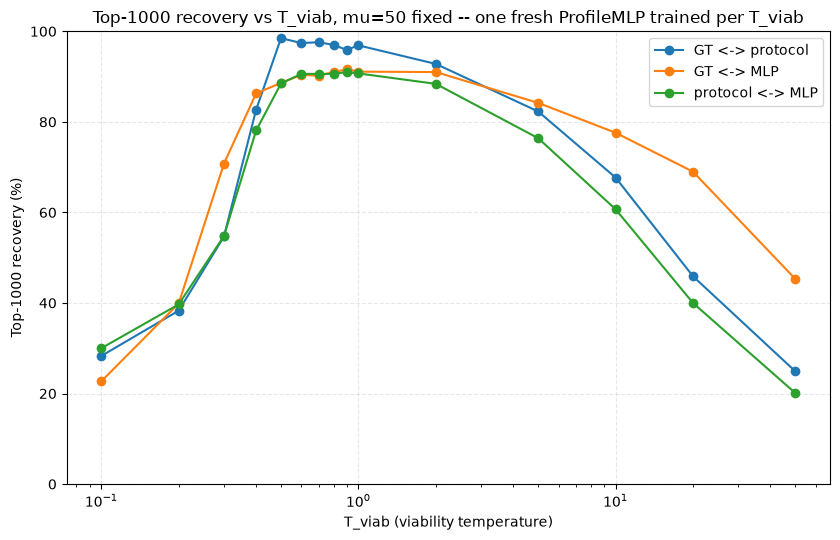

In [12]:
fig, ax = plt.subplots(figsize=(8.5, 5.5))
ax.plot(T_viab_sweep_df["T_viab"], 100 * T_viab_sweep_df["rec_gt_protocol"],  "o-", label="GT <-> protocol")
ax.plot(T_viab_sweep_df["T_viab"], 100 * T_viab_sweep_df["rec_gt_mlp"],       "o-", label="GT <-> MLP")
ax.plot(T_viab_sweep_df["T_viab"], 100 * T_viab_sweep_df["rec_protocol_mlp"], "o-", label="protocol <-> MLP")
ax.set_xscale("log")
ax.set_ylim(0, 100)
ax.set_xlabel("T_viab (viability temperature)")
ax.set_ylabel(f"Top-{K_TOPK} recovery (%)")
ax.set_title(f"Top-{K_TOPK} recovery vs T_viab, mu={MU_FIXED} fixed -- one fresh ProfileMLP trained per T_viab")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.3)
fig.tight_layout()
plt.show()

## 9. Top-1000 recovery on the FIXED 50,000-sequence eval pool vs `T_viab`

Same `50,000` sequences (section 2) at every `T_viab` -- comparable across the whole
grid AND across every other notebook using the same `EVAL_POOL_KEY_SEED=999`/`EVAL_POOL_SIZE=50_000`
pair (e.g. `deeper_mlp/diversity_sweep_deeper_mlp.ipynb`). `GT<->protocol` (gray) comes from section 4's dedicated `protocol_eval` simulation,
mutated to the same `T_viab` as `protocol` at every sweep point (section 6) -- the
natural reference for whether the MLP actually beats the raw protocol measurement on
this common benchmark.

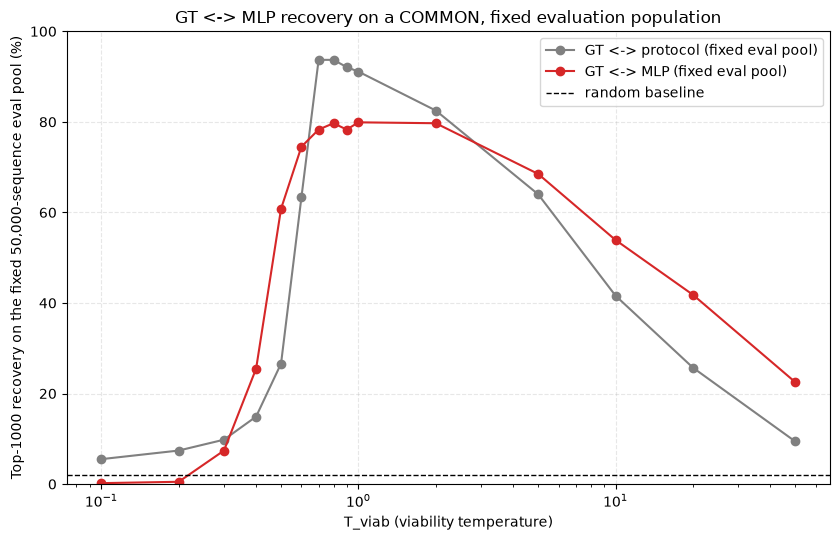

In [13]:
fig, ax = plt.subplots(figsize=(8.5, 5.5))
ax.plot(T_viab_sweep_df["T_viab"], 100 * T_viab_sweep_df["rec_gt_protocol_eval"], "o-", color="gray", label="GT <-> protocol (fixed eval pool)")
ax.plot(T_viab_sweep_df["T_viab"], 100 * T_viab_sweep_df["rec_gt_mlp_eval"], "o-", color="tab:red", label="GT <-> MLP (fixed eval pool)")
ax.axhline(100 * K_TOPK / EVAL_POOL_SIZE, color="black", lw=1, ls="--", label="random baseline")
ax.set_xscale("log")
ax.set_ylim(0, 100)
ax.set_xlabel("T_viab (viability temperature)")
ax.set_ylabel(f"Top-{K_TOPK} recovery on the fixed {EVAL_POOL_SIZE:,}-sequence eval pool (%)")
ax.set_title("GT <-> MLP recovery on a COMMON, fixed evaluation population")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.3)
fig.tight_layout()
plt.show()

## How to read this

- Both curves are expected to be UNIMODAL, not monotonic: `T_viab` too small means a handful of
  top-scoring sequences dominate capsid production with an enormous dynamic range, which can
  saturate/compress the NGS-measured signal for everything else; `T_viab` too large washes the
  score out of the production rate entirely (`exp(score/T_viab) -> 1` for everyone). Signal
  fidelity should peak somewhere in between, not at either extreme.
- Pearson `r` (section 6) is a GLOBAL measure over the whole test fold; top-K recovery (section 7)
  only cares about the extreme tail (the best `K_TOPK` sequences). The two need not peak at the
  same `T_viab` -- a `T_viab` that best preserves the OVERALL ranking is not necessarily the one
  that best preserves WHICH sequences land in the top-K, and vice versa. If they diverge, that is
  itself informative about which regime the experiment should target: pick by Pearson `r` if the
  downstream use needs the whole ranking, pick by top-K recovery if only the very best candidates
  matter (as in `directed_evolution_loop/DE_loopV1.ipynb`).
- **Section 9 (fixed eval pool)** repeats the top-K recovery comparison on a `50,000`-sequence population that's IDENTICAL across every `T_viab` and across every other sweep notebook using the same `EVAL_POOL_KEY_SEED=999` -- use it instead of section 7 when comparing `T_viab`'s effect against a different swept parameter (or a different model architecture) in another notebook.